# NX Heuristic Route Dataset Generation

This notebook builds an alternative seeded-route dataset from ``examples/data/raw_graphs_1000.pkl`` using a shortest-path heuristic inspired by the algorithm you provided: inverse-degree endpoint sampling, repeated shortest-path draws, and a post-pass that tries to insert uncovered nodes into existing routes.

The outputs are saved in the same nested route-file format as ``examples/lc_results`` so they can be loaded by the same downstream helpers, but under a different folder: ``examples/nx_heuristic_results``.


## Outputs

For each graph this notebook writes:

- ``examples/nx_heuristic_results/graph_XXXX/lc_nx_heuristic_graph_XXXX_routes_routes.pkl``
- ``examples/nx_heuristic_results/graph_XXXX/metrics.txt``
- ``examples/nx_heuristic_results/all_results_summary.csv``

The route pickle naming intentionally matches the ``lc_*_routes_routes.pkl`` pattern so ``load_raw_graphs_and_lc_routes(...)`` can read it without code changes.


In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Batch
from tqdm import tqdm

from connectpt.routes_generator.citygraph_dataset import STOP_KEY
from connectpt.routes_generator.improvement_learning import load_raw_graphs_and_lc_routes
from connectpt.routes_generator.torch_utils import dump_routes, get_batch_tensor_from_routes
from connectpt.routes_generator.transit_time_estimator import RouteGenBatchState
from connectpt.routes_generator.utils import get_eval_cfg, process_standard_experiment_cfg


In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "connectpt").exists() and (candidate / "examples").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root from current working directory")


ROOT_DIR = find_repo_root()
CFG_DIR = ROOT_DIR / "connectpt" / "routes_generator" / "cfg"
RAW_GRAPHS_PATH = ROOT_DIR / "examples" / "data" / "raw_graphs_1000.pkl"
OUTPUT_BASE_DIR = ROOT_DIR / "examples" / "nx_heuristic_results"
OUTPUT_BASE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 0
ROUTE_ATTEMPTS = 60
FALLBACK_POOL_SIZE = 10
VIS_GRAPH_INDICES = [0, 125, 250, 375, 500, 625, 750, 875]

GROUP_PARAMS = [
    {"n_routes": 11, "min_route_len": 2, "max_route_len": 15},
    {"n_routes": 12, "min_route_len": 2, "max_route_len": 15},
    {"n_routes": 13, "min_route_len": 2, "max_route_len": 15},
    {"n_routes": 14, "min_route_len": 2, "max_route_len": 15},
]
GROUP_SIZE = 250

# These three weight settings are used for metric evaluation tags only.
# The heuristic route generator itself does not optimize this objective.
WEIGHT_COMBINATIONS = [
    (1.0, 0.0, 0.0),
    (0.0, 1.0, 0.0),
    (0.0, 0.0, 1.0),
]

print(f"ROOT_DIR:        {ROOT_DIR}")
print(f"CFG_DIR:         {CFG_DIR}")
print(f"RAW_GRAPHS_PATH: {RAW_GRAPHS_PATH}")
print(f"OUTPUT_BASE_DIR: {OUTPUT_BASE_DIR}")


ROOT_DIR:        D:\PythonProjects\connectpt
CFG_DIR:         D:\PythonProjects\connectpt\connectpt\routes_generator\cfg
RAW_GRAPHS_PATH: D:\PythonProjects\connectpt\examples\data\raw_graphs_1000.pkl
OUTPUT_BASE_DIR: D:\PythonProjects\connectpt\examples\nx_heuristic_results


In [3]:
random_state = np.random.default_rng(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

graphs_list = pd.read_pickle(RAW_GRAPHS_PATH)
print(f"Loaded raw graphs: {len(graphs_list)} from {RAW_GRAPHS_PATH}")
graphs_list[0]


Loaded raw graphs: 1000 from D:\PythonProjects\connectpt\examples\data\raw_graphs_1000.pkl


CityGraphData(
  fixed_routes=[0, 50],
  street_adj=[50, 50],
  drive_times=[50, 50],
  nexts=[50, 50],
  demand=[50, 50],
  stop={
    pos=[50, 2],
    x=[50, 2],
  },
  (stop, street, stop)={
    edge_index=[2, 130],
    edge_attr=[130, 1],
  },
  (stop, demand, stop)={
    edge_index=[2, 2450],
    edge_attr=[2450, 2],
  }
)

In [4]:
eval_cfg = get_eval_cfg(
    str(CFG_DIR),
    "eval_model_mumford",
    {
        "dataset_name": "tensor",
        "n_routes": 8,
        "min_route_len": 2,
        "max_route_len": 8,
        "run_name": "nx_heuristic_eval",
    },
)
eval_cfg.batch_size = 1

DEVICE, _, _, COST_OBJ, _ = process_standard_experiment_cfg(
    eval_cfg,
    run_name_prefix="nx_heuristic_eval_",
    weights_required=False,
)
COST_OBJ.ignore_stops_oob = False

print(f"Evaluation device: {DEVICE}")
print(f"ignore_stops_oob: {COST_OBJ.ignore_stops_oob}")


Evaluation device: cpu
ignore_stops_oob: False


In [5]:
def build_street_graph(city_graph):
    street_adj = city_graph.street_adj.detach().cpu()
    coords = city_graph[STOP_KEY].pos.detach().cpu().numpy()
    graph_nx = nx.Graph()
    n_nodes = street_adj.shape[0]

    for node_idx in range(n_nodes):
        graph_nx.add_node(
            int(node_idx),
            pos=(float(coords[node_idx, 0]), float(coords[node_idx, 1])),
        )

    for ii in range(n_nodes):
        for jj in range(ii + 1, n_nodes):
            candidates = []
            val_ij = float(street_adj[ii, jj])
            val_ji = float(street_adj[jj, ii])
            if np.isfinite(val_ij):
                candidates.append(val_ij)
            if np.isfinite(val_ji):
                candidates.append(val_ji)
            if candidates:
                graph_nx.add_edge(ii, jj, weight=min(candidates))

    return graph_nx


def node_degree_probabilities(graph_nx):
    inv_deg = {}
    for node, degree in graph_nx.degree():
        inv_deg[node] = 1.0 / degree if degree > 0 else 0.0
    total = sum(inv_deg.values())
    if total <= 0:
        uniform = 1.0 / max(len(inv_deg), 1)
        return {node: uniform for node in inv_deg}
    return {node: value / total for node, value in inv_deg.items()}


def roulette_choice(probabilities, rng):
    nodes = list(probabilities.keys())
    weights = list(probabilities.values())
    return int(rng.choices(nodes, weights=weights, k=1)[0])


def canonical_route(route):
    return tuple(int(node) for node in route)


def precompute_candidate_paths(graph_nx, min_len, max_len):
    candidate_paths = {}
    for source, path_dict in nx.all_pairs_shortest_path(graph_nx):
        for target, path in path_dict.items():
            if source == target:
                continue
            if min_len <= len(path) <= max_len:
                candidate_paths[(int(source), int(target))] = canonical_route(path)
    return candidate_paths


def choose_fallback_path(candidate_paths, used_routes, used_nodes, pool_size, rng):
    remaining = []
    for path in candidate_paths.values():
        if path in used_routes or tuple(reversed(path)) in used_routes:
            continue
        new_nodes = sum(node not in used_nodes for node in path)
        remaining.append((new_nodes, len(path), path))

    if not remaining:
        return None

    remaining.sort(key=lambda item: (item[0], item[1]), reverse=True)
    top_paths = [item[2] for item in remaining[:pool_size]]
    return list(rng.choice(top_paths))


def insert_isolated_nodes(graph_nx, routes, max_len, rng):
    if not routes:
        return routes

    used_nodes = {node for route in routes for node in route}
    isolated_nodes = [node for node in graph_nx.nodes if node not in used_nodes]
    rng.shuffle(isolated_nodes)

    for isolated_node in isolated_nodes:
        route_order = list(range(len(routes)))
        rng.shuffle(route_order)
        inserted = False
        for route_idx in route_order:
            route = routes[route_idx]
            if len(route) >= max_len:
                continue
            for node_pos in range(len(route) - 1):
                left_node = route[node_pos]
                right_node = route[node_pos + 1]
                if graph_nx.has_edge(left_node, isolated_node) and graph_nx.has_edge(isolated_node, right_node):
                    new_route = route[:node_pos + 1] + [isolated_node] + route[node_pos + 1:]
                    if len(new_route) <= max_len:
                        routes[route_idx] = new_route
                        inserted = True
                        break
            if inserted:
                break

    return routes


def generate_initial_routes(graph_nx, num_routes, min_len, max_len, rng, route_attempts=60, fallback_pool_size=10):
    candidate_paths = precompute_candidate_paths(graph_nx, min_len, max_len)
    if not candidate_paths:
        raise ValueError(
            f"No shortest paths found in the length range [{min_len}, {max_len}]"
        )

    probabilities = node_degree_probabilities(graph_nx)
    routes = []
    used_nodes = set()
    used_routes = set()

    for _ in range(num_routes):
        selected_route = None
        for _ in range(route_attempts):
            start_node = roulette_choice(probabilities, rng)
            end_node = roulette_choice(probabilities, rng)
            if start_node == end_node:
                continue
            path = candidate_paths.get((start_node, end_node))
            if path is None:
                continue
            if path in used_routes or tuple(reversed(path)) in used_routes:
                continue
            selected_route = list(path)
            break

        if selected_route is None:
            selected_route = choose_fallback_path(
                candidate_paths,
                used_routes,
                used_nodes,
                fallback_pool_size,
                rng,
            )
        if selected_route is None:
            break

        routes.append(selected_route)
        used_nodes.update(selected_route)
        used_routes.add(canonical_route(selected_route))

    routes = insert_isolated_nodes(graph_nx, routes, max_len, rng)

    while len(routes) < num_routes:
        selected_route = choose_fallback_path(
            candidate_paths,
            used_routes,
            {node for route in routes for node in route},
            fallback_pool_size,
            rng,
        )
        if selected_route is None:
            break
        routes.append(selected_route)
        used_routes.add(canonical_route(selected_route))

    return routes


In [6]:
def make_cost_weights(demand_weight, route_weight, connectivity_weight, device):
    return {
        "demand_time_weight": torch.tensor([float(demand_weight)], device=device),
        "route_time_weight": torch.tensor([float(route_weight)], device=device),
        "median_connectivity_weight": torch.tensor([float(connectivity_weight)], device=device),
    }


def scalarize_metric(value):
    if torch.is_tensor(value):
        value = value.detach().reshape(-1)[0].cpu().item()
    return float(value)


def evaluate_generated_routes(graph, routes, target_n_routes, min_route_len, max_route_len, demand_weight, route_weight, connectivity_weight):
    graph_batch = Batch.from_data_list([graph.clone()]).to(DEVICE)
    route_tensor = get_batch_tensor_from_routes(
        [routes],
        device=DEVICE,
        max_route_len=max_route_len,
    )
    cost_weights = make_cost_weights(
        demand_weight,
        route_weight,
        connectivity_weight,
        DEVICE,
    )
    state = RouteGenBatchState(
        graph_batch,
        COST_OBJ,
        target_n_routes,
        min_route_len,
        max_route_len,
        cost_weights=cost_weights,
    )
    state.add_new_routes(route_tensor)
    result = COST_OBJ(state)
    metrics = {key: scalarize_metric(val) for key, val in result.get_metrics().items()}
    return result, metrics, route_tensor.detach().cpu()


def route_lengths(routes):
    return [len(route) for route in routes]


def plot_route_set(ax, graph, routes, title):
    coords = graph[STOP_KEY].pos.detach().cpu().numpy()
    street_adj = graph.street_adj.detach().cpu().numpy()
    n_nodes = coords.shape[0]

    for start in range(n_nodes):
        for end in range(start + 1, n_nodes):
            if np.isfinite(street_adj[start, end]) or np.isfinite(street_adj[end, start]):
                ax.plot(
                    [coords[start, 0], coords[end, 0]],
                    [coords[start, 1], coords[end, 1]],
                    color="lightgray",
                    linewidth=1.0,
                    alpha=0.45,
                    zorder=1,
                )

    colors = plt.cm.tab20(np.linspace(0, 1, max(1, len(routes))))
    for route_idx, route in enumerate(routes):
        if len(route) < 2:
            continue
        color = colors[route_idx % len(colors)]
        for start, end in zip(route[:-1], route[1:]):
            ax.plot(
                [coords[start, 0], coords[end, 0]],
                [coords[start, 1], coords[end, 1]],
                color=color,
                linewidth=3.0,
                alpha=0.95,
                zorder=3,
            )
        ax.scatter(
            coords[route, 0],
            coords[route, 1],
            color=color,
            s=28,
            edgecolor="white",
            linewidth=0.8,
            zorder=4,
        )

    ax.scatter(coords[:, 0], coords[:, 1], s=40, facecolor="white", edgecolor="black", linewidth=0.8, zorder=5)
    for node_idx, (x_coord, y_coord) in enumerate(coords):
        ax.text(x_coord, y_coord, str(node_idx), fontsize=6, ha="center", va="center", zorder=6)

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")


In [7]:
all_results = []

for graph_idx, graph in enumerate(tqdm(graphs_list, desc="Processing graphs")):
    try:
        group_idx = min(graph_idx // GROUP_SIZE, len(GROUP_PARAMS) - 1)
        group = GROUP_PARAMS[group_idx]
        demand_weight, route_weight, connectivity_weight = WEIGHT_COMBINATIONS[graph_idx % len(WEIGHT_COMBINATIONS)]
        rng = random.Random(RANDOM_SEED + graph_idx)

        graph_nx = build_street_graph(graph)
        routes = generate_initial_routes(
            graph_nx,
            num_routes=group["n_routes"],
            min_len=group["min_route_len"],
            max_len=group["max_route_len"],
            rng=rng,
            route_attempts=ROUTE_ATTEMPTS,
            fallback_pool_size=FALLBACK_POOL_SIZE,
        )

        if len(routes) == 0:
            raise ValueError("The heuristic did not generate any valid routes")

        _, metrics, routes_tensor = evaluate_generated_routes(
            graph,
            routes,
            target_n_routes=group["n_routes"],
            min_route_len=group["min_route_len"],
            max_route_len=group["max_route_len"],
            demand_weight=demand_weight,
            route_weight=route_weight,
            connectivity_weight=connectivity_weight,
        )

        run_name = f"lc_nx_heuristic_graph_{graph_idx:04d}"
        graph_output_dir = OUTPUT_BASE_DIR / f"graph_{graph_idx:04d}"
        graph_output_dir.mkdir(parents=True, exist_ok=True)
        dump_routes(f"{run_name}_routes", routes_tensor, out_dir=graph_output_dir)

        route_len_values = route_lengths(routes)
        covered_nodes = len({node for route in routes for node in route})

        with open(graph_output_dir / "metrics.txt", "w", encoding="utf-8") as file:
            file.write(f"Graph index: {graph_idx}\n")
            file.write(f"Generation method: nx_shortest_path_heuristic\n")
            file.write(f"Group: {group_idx}\n")
            file.write(f"Target n_routes: {group['n_routes']}\n")
            file.write(f"Generated n_routes: {len(routes)}\n")
            file.write(f"min_route_len: {group['min_route_len']}\n")
            file.write(f"max_route_len: {group['max_route_len']}\n")
            file.write(f"weight_combo_index: {graph_idx % len(WEIGHT_COMBINATIONS)}\n")
            file.write("weight_tag_note: metrics are evaluated under this weight tag; generation itself is weight-agnostic\n")
            file.write(f"demand_time_weight: {demand_weight:.4f}\n")
            file.write(f"route_time_weight: {route_weight:.4f}\n")
            file.write(f"median_connectivity_weight: {connectivity_weight:.4f}\n")
            file.write(f"n_nodes: {int(graph[STOP_KEY].num_nodes)}\n")
            file.write(f"covered_nodes: {covered_nodes}\n")
            file.write(f"route_lengths: {route_len_values}\n")
            for key in ["cost", "ATT", "RTT", "# stops out of bounds", "median_connectivity"]:
                if key in metrics:
                    file.write(f"{key}: {metrics[key]:.6f}\n")

        all_results.append({
            "graph_index": graph_idx,
            "group": group_idx,
            "generation_method": "nx_shortest_path_heuristic",
            "n_routes": group["n_routes"],
            "generated_n_routes": len(routes),
            "min_route_len": group["min_route_len"],
            "max_route_len": group["max_route_len"],
            "weight_combo_index": graph_idx % len(WEIGHT_COMBINATIONS),
            "demand_time_weight": demand_weight,
            "route_time_weight": route_weight,
            "median_connectivity_weight": connectivity_weight,
            "run_name": run_name,
            "cost": metrics.get("cost", float("nan")),
            "ATT": metrics.get("ATT", float("nan")),
            "RTT": metrics.get("RTT", float("nan")),
            "unserved_demand": metrics.get("$d_{un}$", float("nan")),
            "n_nodes": int(graph[STOP_KEY].num_nodes),
            "covered_nodes": covered_nodes,
            "route_length_min": min(route_len_values),
            "route_length_mean": float(np.mean(route_len_values)),
            "route_length_max": max(route_len_values),
            "routes": routes,
            "output_dir": str(graph_output_dir),
        })

    except Exception as exc:
        print(f"Error on graph {graph_idx}: {exc}")

summary_path = OUTPUT_BASE_DIR / "all_results_summary.csv"
if all_results:
    df_results = pd.DataFrame([
        {key: value for key, value in row.items() if key not in {"routes", "output_dir"}}
        for row in all_results
    ])
    df_results.to_csv(summary_path, index=False)
    print(f"Summary saved to: {summary_path}")
    display(df_results.head())
else:
    print("No routes were generated.")


Processing graphs: 100%|██████████| 1000/1000 [00:46<00:00, 21.58it/s]

Summary saved to: D:\PythonProjects\connectpt\examples\nx_heuristic_results\all_results_summary.csv


,graph_index,group,generation_method,n_routes,generated_n_routes,min_route_len,max_route_len,weight_combo_index,demand_time_weight,route_time_weight,...,run_name,cost,ATT,RTT,unserved_demand,n_nodes,covered_nodes,route_length_min,route_length_mean,route_length_max
0,0,0,nx_shortest_path_heuristic,11,11,2,15,0,1.0,0.0,...,lc_nx_heuristic_graph_0000,2.879114,39.824131,865.744995,30.990368,50,42,3,8.181818,14
1,1,0,nx_shortest_path_heuristic,11,11,2,15,1,0.0,1.0,...,lc_nx_heuristic_graph_0001,2.481452,33.803417,858.609741,14.614542,50,46,4,8.636364,15
2,2,0,nx_shortest_path_heuristic,11,11,2,15,2,0.0,0.0,...,lc_nx_heuristic_graph_0002,3.122616,40.325722,752.198181,50.141270,50,36,2,6.727273,13
3,3,0,nx_shortest_path_heuristic,11,11,2,15,0,1.0,0.0,...,lc_nx_heuristic_graph_0003,4.332521,34.687759,815.320679,52.681381,50,35,4,8.000000,13
4,4,0,nx_shortest_path_heuristic,11,11,2,15,1,0.0,1.0,...,lc_nx_heuristic_graph_0004,3.831109,38.557060,738.634888,52.981556,50,35,2,7.090909,11


In [8]:
if all_results:
    df_results = pd.DataFrame([
        {key: value for key, value in row.items() if key not in {"routes", "output_dir"}}
        for row in all_results
    ])

    print("\n" + "=" * 60)
    print("HEURISTIC DATASET SUMMARY")
    print("=" * 60)
    print(f"Generated graphs: {len(df_results)}")
    print(f"Average generated routes: {df_results['generated_n_routes'].mean():.2f}")
    print(f"Average covered nodes:    {df_results['covered_nodes'].mean():.2f}")

    for group_idx, group in enumerate(GROUP_PARAMS):
        group_df = df_results[df_results['group'] == group_idx]
        if group_df.empty:
            continue
        print(
            f"\nGroup {group_idx} | target routes={group['n_routes']} | "
            f"len={group['min_route_len']}?{group['max_route_len']} | graphs={len(group_df)}"
        )
        print(f"  generated routes: mean={group_df['generated_n_routes'].mean():.2f}")
        print(f"  covered nodes:    mean={group_df['covered_nodes'].mean():.2f}")
        print(f"  cost:             mean={group_df['cost'].mean():.4f}")
        print(f"  ATT:              mean={group_df['ATT'].mean():.4f}")
        print(f"  RTT:              mean={group_df['RTT'].mean():.4f}")



HEURISTIC DATASET SUMMARY
Generated graphs: 1000
Average generated routes: 12.50
Average covered nodes:    42.20

Group 0 | target routes=11 | len=2?15 | graphs=250
  generated routes: mean=11.00
  covered nodes:    mean=40.76
  cost:             mean=3.1210
  ATT:              mean=37.5480
  RTT:              mean=717.7287

Group 1 | target routes=12 | len=2?15 | graphs=250
  generated routes: mean=12.00
  covered nodes:    mean=42.04
  cost:             mean=2.8623
  ATT:              mean=37.7244
  RTT:              mean=763.8237

Group 2 | target routes=13 | len=2?15 | graphs=250
  generated routes: mean=13.00
  covered nodes:    mean=42.72
  cost:             mean=2.7124
  ATT:              mean=37.3012
  RTT:              mean=828.4579

Group 3 | target routes=14 | len=2?15 | graphs=250
  generated routes: mean=14.00
  covered nodes:    mean=43.26
  cost:             mean=2.6129
  ATT:              mean=37.0397
  RTT:              mean=863.3026


In [9]:
generated_graphs, generated_seed_routes = load_raw_graphs_and_lc_routes(
    RAW_GRAPHS_PATH,
    OUTPUT_BASE_DIR,
)

route_files = sorted(OUTPUT_BASE_DIR.glob("graph_*/lc_*_routes_routes.pkl"))
route_lengths = (generated_seed_routes >= 0).sum(dim=-1)
print(f"Graphs loaded:      {len(generated_graphs)}")
print(f"Route files found:  {len(route_files)}")
print(f"Seed routes shape:  {tuple(generated_seed_routes.shape)}")
print(f"Route length min:   {int(route_lengths[route_lengths > 0].min())}")
print(f"Route length max:   {int(route_lengths.max())}")


Graphs loaded:      1000
Route files found:  1000
Seed routes shape:  (1000, 14, 15)
Route length min:   2
Route length max:   15


## Visualization of Several Generated Graphs


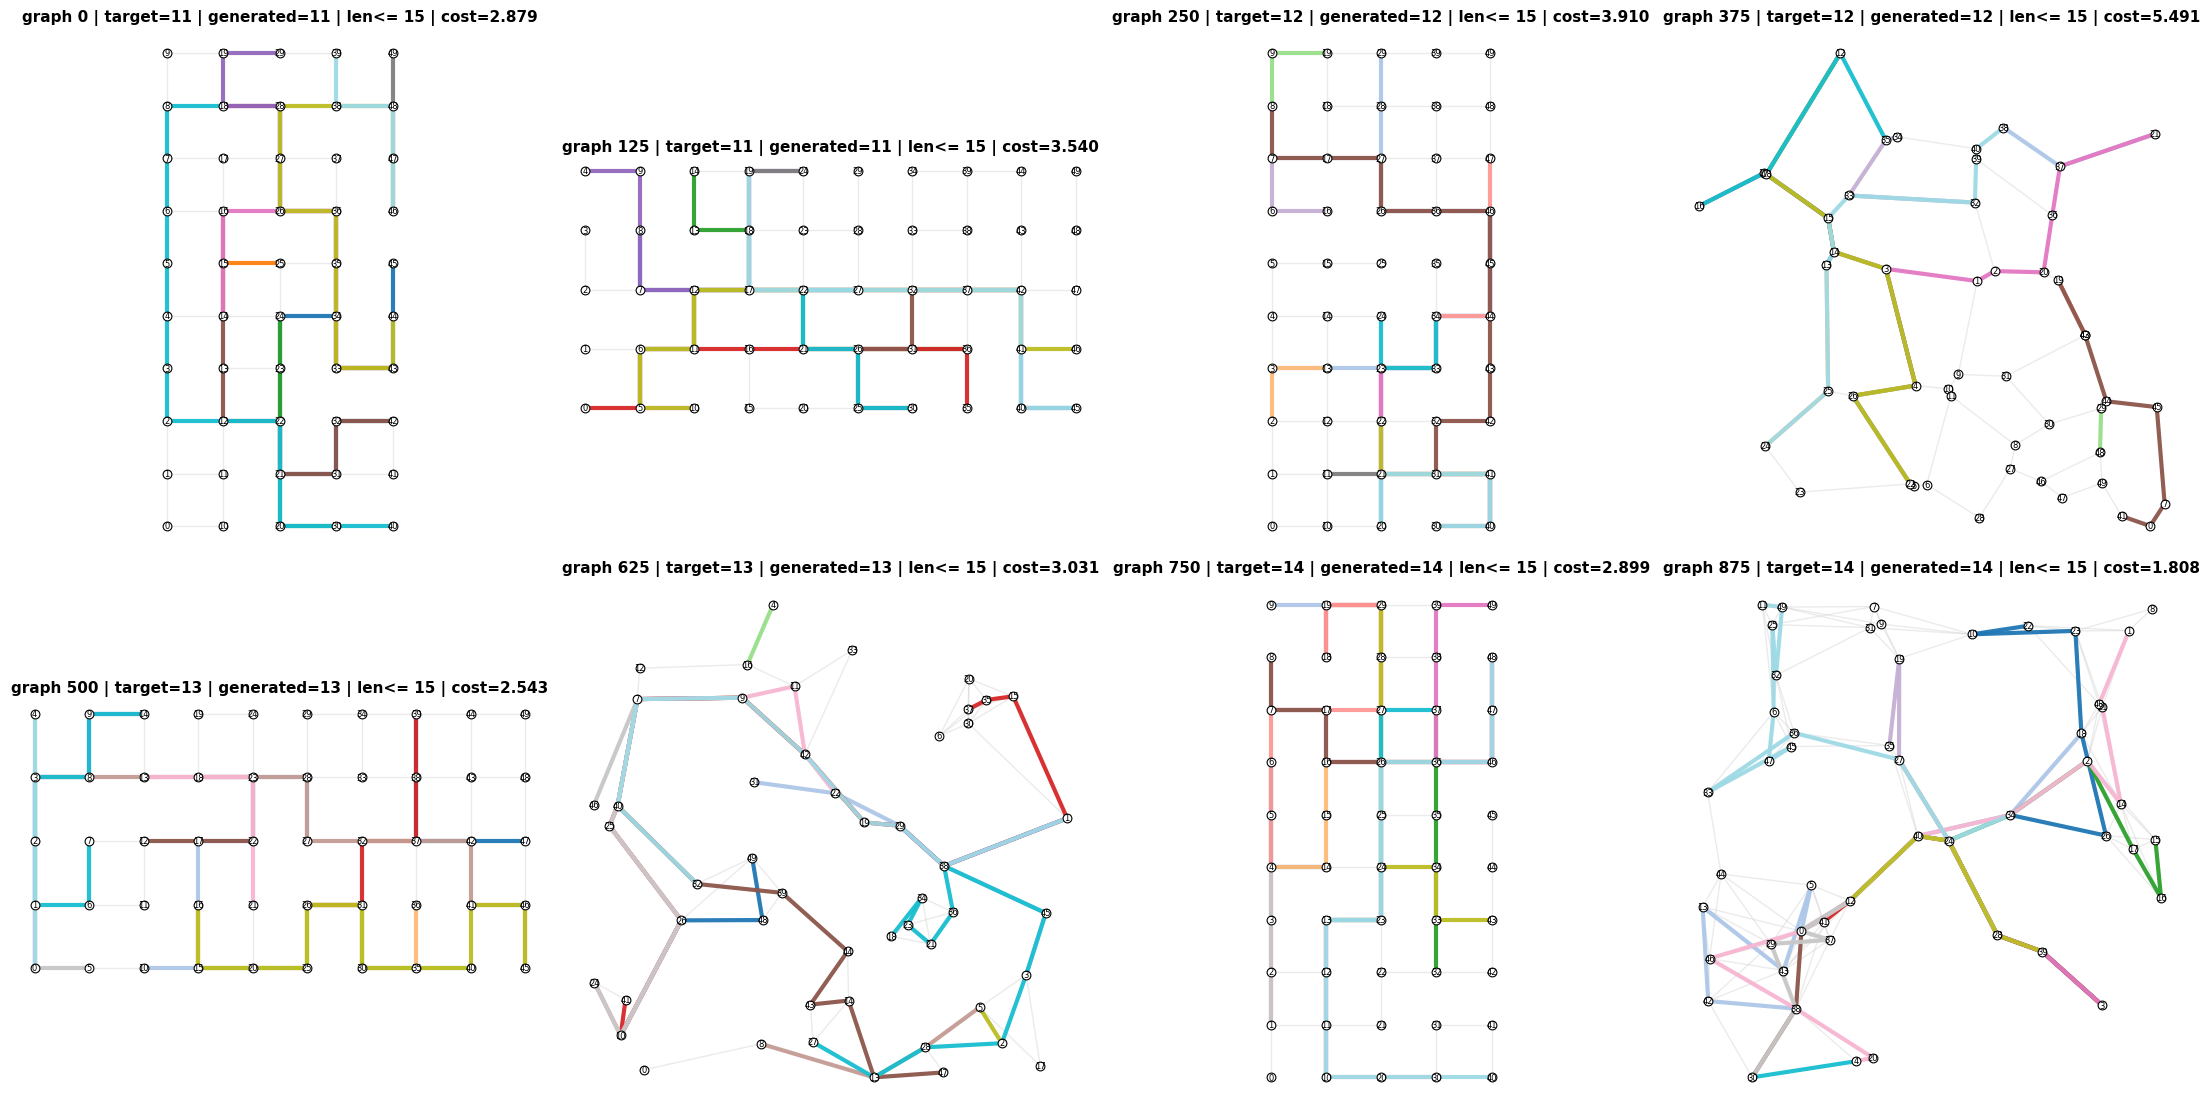

,graph_index,target_n_routes,generated_n_routes,max_route_len,covered_nodes,cost,ATT,RTT,routes
0,0,11,11,15,42,2.879114,39.824131,865.744995,"[[45, 44, 43, 33, 34, 24, 23, 22, 21, 31, 32, ..."
1,125,11,11,15,33,3.540121,33.102394,1040.537231,"[[45, 40, 41, 42, 37, 32, 27, 22, 17, 12, 7, 8..."
2,250,12,12,15,34,3.909994,40.820362,826.571533,"[[20, 21, 22, 23, 33, 34, 44, 45, 46], [29, 28..."
3,375,12,12,15,37,5.490555,19.619253,433.547546,"[[12, 18, 15, 14, 13], [21, 37, 38], [13, 25, ..."
4,500,13,13,15,40,2.543334,41.490047,912.329834,"[[39, 38, 37, 42, 47], [27, 28, 23, 22, 17, 16..."
5,625,13,13,15,43,3.030582,37.773769,879.078003,"[[49, 48, 26, 10], [31, 22, 29, 38, 45, 3], [1..."
6,750,14,14,15,42,2.898581,37.617546,1068.281616,"[[14, 4, 5, 6], [9, 19, 29], [47, 46, 36, 26, ..."
7,875,14,14,15,45,1.808016,39.429829,871.173035,"[[22, 10, 23, 18, 26, 34], [38, 42, 13, 43, 5,..."


In [10]:
result_by_graph = {row['graph_index']: row for row in all_results}
selected_graph_indices = [idx for idx in VIS_GRAPH_INDICES if idx in result_by_graph]
if not selected_graph_indices:
    selected_graph_indices = [row['graph_index'] for row in all_results[:8]]

n_plots = max(len(selected_graph_indices), 1)
n_cols = 4 if n_plots >= 8 else 3 if n_plots >= 6 else 2
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.5 * n_cols, 5.5 * n_rows),
    constrained_layout=True,
    squeeze=False,
)
axes = axes.flatten()

for ax, graph_idx in zip(axes, selected_graph_indices):
    row = result_by_graph[graph_idx]
    subtitle = (
        f"graph {graph_idx} | target={row['n_routes']} | generated={row['generated_n_routes']} | "
        f"len<= {row['max_route_len']} | cost={row['cost']:.3f}"
    )
    plot_route_set(ax, graphs_list[graph_idx], row['routes'], subtitle)

for ax in axes[len(selected_graph_indices):]:
    ax.axis("off")

plt.show()

display(
    pd.DataFrame([
        {
            "graph_index": result_by_graph[idx]['graph_index'],
            "target_n_routes": result_by_graph[idx]['n_routes'],
            "generated_n_routes": result_by_graph[idx]['generated_n_routes'],
            "max_route_len": result_by_graph[idx]['max_route_len'],
            "covered_nodes": result_by_graph[idx]['covered_nodes'],
            "cost": result_by_graph[idx]['cost'],
            "ATT": result_by_graph[idx]['ATT'],
            "RTT": result_by_graph[idx]['RTT'],
            "routes": result_by_graph[idx]['routes'],
        }
        for idx in selected_graph_indices
    ])
)
